##IMPORTING LIBRARIES

In [ ]:
!pip install py_vollib-vectorized
!pip install utils

In [ ]:
import numpy as np
import requests
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from datetime import datetime
from py_vollib_vectorized import vectorized_implied_volatility as implied_vol
from datetime import datetime, timedelta
from matplotlib.dates import date2num, DateFormatter, DayLocator
from scipy.interpolate import griddata
# from utils import process_asset_data, process_treasury_data, calculate_rolling_volatility
# from pricing_models import HestonModel, OptionPricer
from scipy.integrate import quad
from scipy.optimize import minimize
import warnings
from scipy.stats import norm
from typing import List

##STOCK DATA FROM YFINANCE

In [ ]:
# Asset Data
ticker = 'BTC-USD'
asset_data = yf.download(ticker, '2014-01-01', datetime.today(), auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [ ]:
asset_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-07-26,117947.367188,118335.687500,117181.226562,117644.843750,48508954046
2025-07-27,119448.492188,119815.593750,117859.687500,117944.726562,54683390892
2025-07-28,117924.476562,119819.789062,117441.437500,119457.523438,64822943193
2025-07-29,117922.148438,119273.867188,116987.367188,117938.585938,68463107433
2025-07-30,117072.390625,118650.179688,116000.539062,117913.367188,69182668800


In [ ]:
df = pd.DataFrame(asset_data['Close'])
df.reset_index(inplace=True)
df.rename(columns={ticker:'Close'},inplace=True)
df['Change in asset returns'] = df['Close']/df['Close'].shift(1)

In [ ]:
df.columns

Index(['Date', 'Close', 'Change in asset returns'], dtype='object', name='Ticker')

In [ ]:
df.tail()

Ticker,Date,Close,Change in asset returns
3965,2025-07-26,117947.367188,1.002648
3966,2025-07-27,119448.492188,1.012727
3967,2025-07-28,117924.476562,0.987241
3968,2025-07-29,117922.148438,0.999980
3969,2025-07-30,117072.390625,0.992794


In [ ]:
trading_days=365
window=21

# Convert to pandas Series if not already
prices = pd.Series(df['Close'])
# Calculate simple returns
returns = prices.pct_change()
# Calculate rolling standard deviation
rolling_std = returns.rolling(window=window).var()

df['rolling_vol']=rolling_std * np.sqrt(trading_days)

In [ ]:
df.tail()

Ticker,Date,Close,Change in asset returns,rolling_vol
3965,2025-07-26,117947.367188,1.002648,0.002891
3966,2025-07-27,119448.492188,1.012727,0.002928
3967,2025-07-28,117924.476562,0.987241,0.003028
3968,2025-07-29,117922.148438,0.999980,0.003038
3969,2025-07-30,117072.390625,0.992794,0.002848


In [ ]:
Q = list(df['Change in asset returns'][22:]) # Vector of change in asset returns
V = list(df['rolling_vol'][22:]) # Vector of 21 day (monthly) rolling volatility

##OPTIONS DATA FROM DERIBIT

In [ ]:
yfticker = yf.Ticker(ticker)
strike_dates = yfticker.options
strike_dates

()

In [ ]:
options_data = pd.DataFrame(requests.get("https://www.deribit.com/api/v2/public/get_book_summary_by_currency", params={"currency": "BTC", "kind": "option"}).json()["result"])

In [ ]:
options_data.head()

,high,low,last,instrument_name,bid_price,ask_price,open_interest,mark_price,creation_timestamp,price_change,mark_iv,underlying_price,underlying_index,interest_rate,volume,estimated_delivery_price,base_currency,quote_currency,volume_usd,mid_price
0,0.0021,0.0019,0.0020,BTC-26SEP25-80000-P,0.0020,0.0023,3094.3,0.002159,1753910849005,-4.7619,53.22,118296.090000,BTC-26SEP25,0.0,0.8,117030.95,BTC,BTC,182.28,0.00215
1,0.0003,0.0003,0.0003,BTC-26SEP25-40000-P,0.0002,0.0004,501.5,0.000288,1753910849005,0.0000,103.03,118296.090000,BTC-26SEP25,0.0,58.8,117030.95,BTC,BTC,2080.71,0.00030
2,0.0115,0.0014,0.0027,BTC-31JUL25-117500-C,0.0021,0.0026,35.9,0.002350,1753910849005,-76.5217,29.05,117034.526884,SYN.BTC-31JUL25,0.0,44.9,117030.95,BTC,BTC,34979.36,0.00235
3,NaN,NaN,0.2285,BTC-27MAR26-105000-C,0.2200,0.2230,531.0,0.221397,1753910849005,NaN,46.07,122777.010000,BTC-27MAR26,0.0,0.0,117030.95,BTC,BTC,0.00,0.22150
4,NaN,NaN,0.0016,BTC-27MAR26-40000-P,0.0013,0.0020,231.6,0.001651,1753910849005,NaN,64.52,122777.010000,BTC-27MAR26,0.0,0.0,117030.95,BTC,BTC,0.00,0.00165


In [ ]:
# 1. Filter for call options
options_data = options_data[options_data["instrument_name"].str.endswith("C")].copy()

options_data["strike"] = options_data["instrument_name"].str.extract(r"-(\d+)-C")[0].astype(float)
options_data["expiry"] = pd.to_datetime(options_data["instrument_name"].str.extract(r"-(\d+[A-Z]+\d+)-")[0], format="%d%b%y", errors="coerce")
options_data["contractSymbol"] = options_data["instrument_name"]
options_data["strike_dates"] = pd.to_datetime(options_data["instrument_name"].str.extract(r"-(\d+[A-Z]+\d+)-")[0],format="%d%b%y",errors="coerce").dt.strftime("%Y-%m-%d")
options_data["lastPrice"] = (options_data["bid_price"] + options_data["ask_price"]) / 2
options_data["bid"] = options_data["bid_price"]
options_data["ask"] = options_data["ask_price"]
options_data["impliedVolatility"] = options_data["mark_iv"]
options_data["inTheMoney"] = options_data["strike"] < options_data["underlying_price"]
options_data["contractSize"] = "REGULAR"
options_data["currency"] = "USD"

# 4. Select and reorder columns
df_calls = options_data[[
    "contractSymbol", "strike","strike_dates","lastPrice", "bid", "ask","impliedVolatility","inTheMoney", "contractSize", "currency"
]]
df_calls = df_calls.sort_values(by="strike_dates").reset_index(drop=True)
df_calls['lastPrice'] *= df['Close'].iloc[-1]

In [ ]:
df_calls

,contractSymbol,strike,strike_dates,lastPrice,bid,ask,impliedVolatility,inTheMoney,contractSize,currency
0,BTC-31JUL25-117500-C,117500.0,2025-07-31,275.120118,0.0021,0.0026,29.05,False,REGULAR,USD
1,BTC-31JUL25-116500-C,116500.0,2025-07-31,790.238637,0.0060,0.0075,29.90,True,REGULAR,USD
2,BTC-31JUL25-134000-C,134000.0,2025-07-31,NaN,NaN,0.0001,67.74,False,REGULAR,USD
3,BTC-31JUL25-124000-C,124000.0,2025-07-31,NaN,NaN,0.0001,61.45,False,REGULAR,USD
4,BTC-31JUL25-116000-C,116000.0,2025-07-31,1199.992004,0.0095,0.0110,31.41,True,REGULAR,USD
...,...,...,...,...,...,...,...,...,...,...
392,BTC-26JUN26-240000-C,240000.0,2026-06-26,2751.201180,0.0225,0.0245,49.12,False,REGULAR,USD
393,BTC-26JUN26-380000-C,380000.0,2026-06-26,515.118519,0.0041,0.0047,53.53,False,REGULAR,USD
394,BTC-26JUN26-360000-C,360000.0,2026-06-26,643.898148,0.0050,0.0060,53.08,False,REGULAR,USD
395,BTC-26JUN26-125000-C,125000.0,2026-06-26,20516.936457,0.1735,0.1770,46.63,False,REGULAR,USD


##HESTON MODEL, OPTION PRICER & MLEOPTIMIZER

In [ ]:
class HestonModel:
    def __init__(self, S0, r, kappa, theta, sigma, rho, v0):
        self.S0 = S0
        self.r = r
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma
        self.rho = rho
        self.v0 = v0

    def heston_characteristic_function(self, phi, T):
        """ Compute the Heston Model Characteristic Function"""
        # Parameters
        tau = T
        i = complex(0, 1)

        # Compute M and N
        M = np.sqrt((self.rho * self.sigma * i * phi - self.kappa)**2 + self.sigma**2 * (i * phi + phi**2))
        N = (self.rho * self.sigma * i * phi - self.kappa - M) / (self.rho * self.sigma * i * phi - self.kappa + M)

        # Compute A, B, C
        A = self.r * i * phi * tau + (self.kappa * self.theta / self.sigma**2) * (
            -(self.rho * self.sigma * i * phi - self.kappa - M) * tau - 2 * np.log((1 - N * np.exp(M * tau)) / (1 - N))
        )
        B = 0
        C = ((np.exp(M * tau) - 1) * (self.rho * self.sigma * i * phi - self.kappa - M)) / (self.sigma**2 * (1 - N * np.exp(M * tau)))

        # Characteristic function
        f = np.exp(A + B * np.log(self.S0) + C * self.v0 + i * phi * np.log(self.S0))
        return f

    def integrand(self, phi, K, T, flag):
        """Integrand for the option price formula"""
        i = complex(0, 1)
        if flag == 1:
            f = self.heston_characteristic_function(phi - i, T)
            return np.real((K**(-i * phi) * f) / (i * phi))
        else:
            f = self.heston_characteristic_function(phi, T)
            return np.real((K**(-i * phi) * f) / (i * phi))

    def heston_option_price(self, K, T):
        """Compute the Heston Model option price"""
        # Compute the two integrals using numerical integration
        integral1, _ = quad(self.integrand, 0, 100, args=(K, T, 1))
        integral2, _ = quad(self.integrand, 0, 100, args=(K, T, 2))

        # Option price formula
        C = 0.5 * self.S0 + (np.exp(-self.r * T) / np.pi) * integral1 - K * np.exp(-self.r * T) * (0.5 + (1 / np.pi) * integral2)
        return C

    def heston_monte_carlo(self, T, N, mu, num_sims=500):
        """Monte Carlo simulation of the Heston Model"""
        dt = T/N # Time step size
        # Generate correlated Brownian motions for all simulations at once
        dW2 = np.random.normal(0, 1, size=(num_sims, N))
        dW1 = self.rho * dW2 + np.sqrt(1 - self.rho**2) * np.random.normal(0, 1, size=(num_sims, N))

        # Initialize arrays for stock prices and volatilities
        S = np.zeros((num_sims, N+1))
        V = np.zeros((num_sims, N+1))
        S[:, 0] = self.S0
        V[:, 0] = self.v0

        # Vectorized Euler-Maruyama method
        for i in range(N):
            V[:, i+1] = V[:, i] + self.kappa * (self.theta - np.maximum(V[:, i], 0)) * dt + self.sigma * np.sqrt(np.maximum(V[:, i], 0)) * dW2[:, i] * np.sqrt(dt)
            # Use full truncation scheme to ensure volatility stays positive
            V[:, i+1] = np.maximum(V[:, i+1], 0)
            S[:, i+1] = S[:, i] * (1 + mu * dt + np.sqrt(V[:, i]) * dW1[:, i] * np.sqrt(dt))
            #S[:, i+1] = S[:, i] * np.exp((mu - 0.5 * V[:, i]) * dt + np.sqrt(V[:, i]) * np.sqrt(dt) * dW1[:, i])

        return S, V

class OptionPricer(HestonModel):
    def __init__(self, S0, r, kappa, theta, sigma, rho, v0, option_type = 'call', pricer='heston'):
        super().__init__(S0, r, kappa, theta, sigma, rho, v0)
        self.option_type = option_type
        self.pricer = pricer

    def MC_call_pricing(self, S, trading_days, strike):
        """Heston Monte Carlo pricing of European call options"""
        S_T = np.array([x[trading_days-1] for x in S])
        call_payoffs = np.maximum(S_T - strike, 1e-15)
        call_price = np.mean(call_payoffs)

        # Calculate discounted expected payoff
        call_price = call_price * np.exp(-self.r*(trading_days/252))
        return call_price

    # def MC_put_prices(self, S, trading_days, strike):
    #     """Heston Monte Carlo pricing of European put options"""
    #     S_T = np.array([x[trading_days-1] for x in S])
    #     put_payoffs = np.maximum(strike - S_T, 0)
    #     put_price = np.mean(put_payoffs)

    #     # Calculate discounted expected payoff
    #     put_price = put_price * np.exp(-self.r*(trading_days/252))
    #     return put_price

    def BS_CALL(self, T, K):
        """Black-Scholes pricing of European call options"""
        N = norm.cdf
        d1 = (np.log(self.S0/K) + (self.r + self.sigma**2/2)*T) / (self.sigma*np.sqrt(T))
        d2 = d1 - self.sigma * np.sqrt(T)
        return self.S0 * N(d1) - K * np.exp(-self.r*T)* N(d2)

    # def BS_PUT(self, T, K):
    #     """Black-Scholes pricing of European put options"""
    #     N = norm.cdf
    #     d1 = (np.log(self.S0/K) + (self.r + self.sigma**2/2)*T) / (self.sigma*np.sqrt(T))
    #     d2 = d1 - self.sigma* np.sqrt(T)
    #     return K*np.exp(-self.r*T)*N(-d2) - self.S0*N(-d1)


    def price_options(self, strikes, trading_days, S=None):
        """Price options using the specified pricer"""
        if self.pricer == 'heston' and self.option_type == 'call':
            option_prices = [self.heston_option_price(K, trading_days/252) for K in strikes]

        elif self.pricer == 'monte_carlo' and self.option_type == 'call':
            option_prices = [self.MC_call_pricing(S,trading_days, K) for K in strikes]

        # elif self.pricer == 'monte_carlo' and self.option_type == 'put':
        #     option_prices = [self.MC_put_prices(S, trading_days, K) for K in strikes]

        elif self.pricer == 'black_scholes' and self.option_type == 'call':
            option_prices = [self.BS_CALL(trading_days/252, K) for K in strikes]

        # elif self.pricer == 'black_scholes' and self.option_types == 'put':
        #     option_prices = [self.BS_PUT(trading_days/252, K) for K in strikes]

        return option_prices

In [ ]:
class MLEOptimizer:
    def __init__(self, Q, V, r, n_guesses=10):
        self.Q = np.array(Q)
        self.V = np.array(V)
        self.r = r
        self.n_guesses = n_guesses

    def transform_parameters(self, x):
        x1, x2, x3, x4 = x
        k     = 0.5 + 4.5 * (1 / (1 + np.exp(-x1)))
        theta = 1   / (1 + np.exp(-x2))
        sigma = 5   / (1 + np.exp(-x3))
        rho   = -1  / (1 + np.exp(-x4))
        return np.array([k, theta, sigma, rho])

    def transform_parameters_inverse(self, params):
        k, theta, sigma, rho = params
        try:
            x1 = -np.log((4.5/(k - 0.5)) - 1)
            x2 = -np.log((1/theta)   - 1)
            x3 = -np.log((5/sigma)   - 1)
            x4 = -np.log((-1/rho)    - 1)
            return np.array([x1, x2, x3, x4])
        except Exception:
            return np.full(4, np.nan)

    def log_likelihood_transformed(self, x):
        params = self.transform_parameters(x)
        k, θ, σ, ρ = params
        Q, V, r = self.Q, self.V, self.r
        n = len(V) - 1
        ll = 0.0
        try:
            for t in range(n):
                term1 = -np.log(2*np.pi) - np.log(σ) - np.log(V[t])
                term2 = -0.5 * np.log(1 - ρ**2)
                ΔQ  = Q[t+1] - 1 - r
                ΔV  = V[t+1] - V[t] - θ*k + k*V[t]
                frac1 = -ΔQ**2 / (2*V[t]*(1-ρ**2))
                frac2 =  ρ * ΔQ * ΔV / (V[t]*σ*(1-ρ**2))
                frac3 = -ΔV**2 / (2*σ**2 * V[t] * (1-ρ**2))
                ll += term1 + term2 + frac1 + frac2 + frac3
        except:
            return np.inf  # optimizer will skip
        return -ll

    def generate_initial_guesses(self):
        eps = 1e-6
        guesses = []
        for _ in range(self.n_guesses):
            k     = np.random.uniform(0.5+eps, 5-eps)
            θ     = np.random.uniform(0+eps,   1-eps)
            σ     = np.random.uniform(0+eps,   5-eps)
            ρ     = np.random.uniform(-1+eps,  0-eps)
            guesses.append([k, θ, σ, ρ])
        return guesses

    def estimate_parameters_robust(self):
        initial_guesses = self.generate_initial_guesses()
        best = {'likelihood': -np.inf, 'result': None}
        methods = ['L-BFGS-B', 'SLSQP', 'TNC']

        for guess in initial_guesses:
            x0 = self.transform_parameters_inverse(guess)
            if not np.isfinite(x0).all():
                continue

            for m in methods:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    res = minimize(self.log_likelihood_transformed,
                                   x0, method=m,
                                   options={'maxiter':1000,'ftol':1e-8,'gtol':1e-8})
                if res.success:
                    ll = -res.fun
                    if ll > best['likelihood']:
                        best = {
                            'likelihood': ll,
                            'result':    res,
                            'method':    m,
                            'initial':   guess
                        }

        if best['result'] is None:
            raise ValueError("Optimization failed for all attempts")

        params = self.transform_parameters(best['result'].x)
        return {
            'k':     params[0],
            'theta': params[1],
            'sigma': params[2],
            'rho':   params[3],
            'log_likelihood': best['likelihood'],
            'method':         best['method'],
            'initial_guess':  best['initial'],
            'message':        best['result'].message
        }


##HESTON PARAMETER ESTIMATION

In [ ]:
def process_treasury_data(treasury_data):
    df_treasury = pd.DataFrame(treasury_data['Close'])
    df_treasury.columns = ['3M', '5Y', '10Y', '30Y']
    df_treasury.reset_index(inplace=True)

    return df_treasury

In [ ]:
# Fetch U.S. Treasury yield data from yfinance
tickers = ['^IRX', '^FVX', '^TNX', '^TYX']  # 3-month, 5-year, 10-year, and 30-year Treasury yield indices
treasury_data = yf.download(tickers, start=datetime.today() - timedelta(days=4), end=datetime.today())
df_treasury = process_treasury_data(treasury_data)

r = np.log(1+df_treasury['3M'].values[-1]/100) #Using 3 month treasury yield as proxy for risk free rate

/tmp/ipython-input-3721857498.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  treasury_data = yf.download(tickers, start=datetime.today() - timedelta(days=4), end=datetime.today())
[*********************100%***********************]  4 of 4 completed


In [ ]:
#Heston Parameter Estimation
mle = MLEOptimizer(Q,V, r, n_guesses=20)
results = mle.estimate_parameters_robust()

In [ ]:
S0 =df['Close'].iloc[-1]           # BTC spot price
kappa = results['k']               # Mean reversion rate
theta = results['theta']           # Long-term average volatility
sigma = results['sigma']           # Volatility of volatility
rho   = results['rho']             # Correlation coefficient
v0 = df['rolling_vol'].mean()      # Initial volatility


In [ ]:
# kappa = 0.5000000189962837       # Mean reversion rate
# theta = 0.007976000586386653     # Long-term average volatility
# sigma = 0.06057037683070126      # Volatility of volatility
# rho = -0.04242212733835123       # Correlation coefficient


#q = 0.0          # Cost of carry / funding rate (set to 0 if no adjustment)
# K = 32000        # Strike price

##MONTE CARLO SIMULATION

In [ ]:
model = HestonModel(S0, r, kappa, theta, sigma, rho, v0)

In [ ]:
T = 1               # Time to maturity in years
N = 252             # Assuming 252 trading days in a year
mu = r              # Drift term is equal to risk-free rate
num_sims = 1000     # Number of Monte Carlo simulations

# Run Monte Carlo Simulation
S, V = model.heston_monte_carlo(T, N, mu, num_sims)

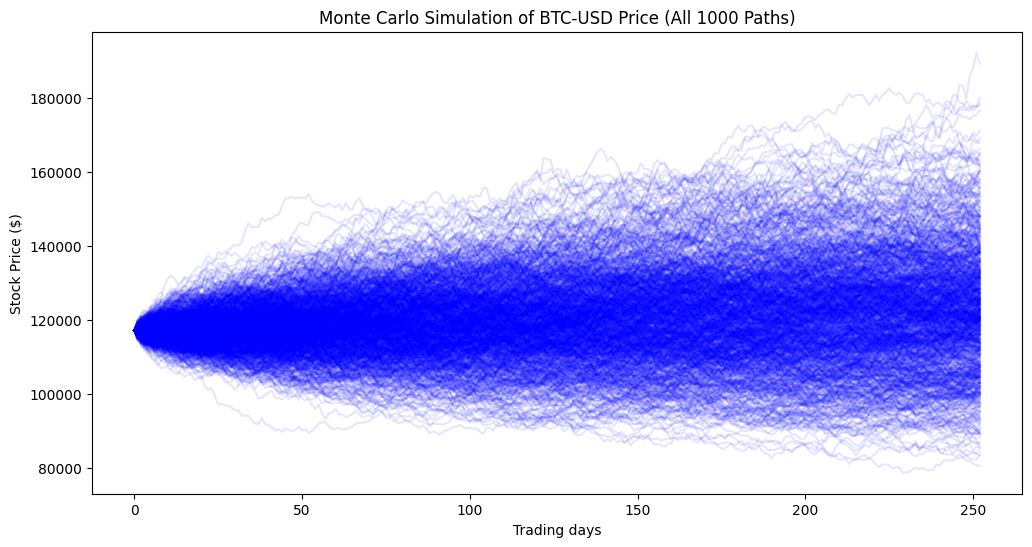

In [ ]:
# Plot all 1000 simulation paths
plt.figure(figsize=(12, 6))
plt.plot(S.T, color="blue", alpha=0.1)  # Transpose S so each column represents a path

# Formatting
plt.xlabel("Trading days")
plt.ylabel("Stock Price ($)")
plt.title("Monte Carlo Simulation of {} Price (All {} Paths)".format(ticker, num_sims))
plt.show()

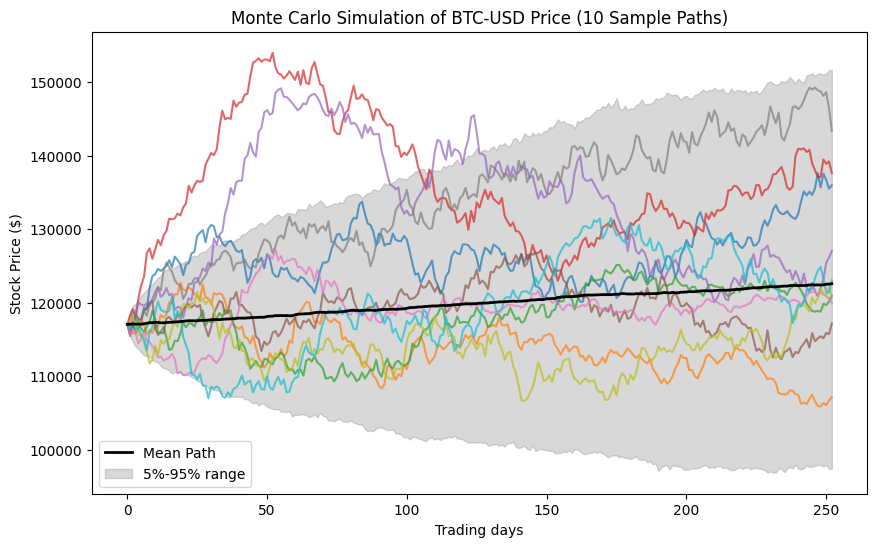

In [ ]:
# Plot multiple sample paths
plt.figure(figsize=(10, 6))
for i in range(10):  # Plot only 10 paths for clarity
    plt.plot(S[i, :], alpha=0.7)

# Plot mean and confidence bands
mean_path = np.mean(S, axis=0)
percentile_5 = np.percentile(S, 5, axis=0)
percentile_95 = np.percentile(S, 95, axis=0)

plt.plot(mean_path, color="black", linewidth=2, label="Mean Path")
plt.fill_between(range(S.shape[1]), percentile_5, percentile_95, color="gray", alpha=0.3, label="5%-95% range")

plt.xlabel("Trading days")
plt.ylabel("Stock Price ($)")
plt.title("Monte Carlo Simulation of {} Price (10 Sample Paths)".format(ticker))
plt.legend()
plt.show()

##BTC OPTION PRICING

In [ ]:
exp_date=df_calls['strike_dates'][10]
df_calls = df_calls[df_calls['strike_dates'] == exp_date].reset_index(drop=True)

In [ ]:
strikes = df_calls['strike'].values  # use actual Deribit strikes
today_date = datetime.today().strftime('%Y-%m-%d')

trading_days = len(pd.bdate_range(start=today_date, end=exp_date))

In [ ]:
today_date

'2025-07-30'

In [ ]:
exp_date

'2025-07-31'

In [ ]:
hes_price_model = OptionPricer(S0, r, kappa, theta, sigma, rho, v0, option_type = 'call', pricer='heston')
heston_call_prices = hes_price_model.price_options(strikes, trading_days)

mc_price_model = OptionPricer(S0, r, kappa, theta, sigma, rho, v0, option_type = 'call', pricer='monte_carlo')
monte_carlo_call_prices = mc_price_model.price_options(strikes, trading_days, S)

bs_price_model = OptionPricer(S0, r, kappa, theta, sigma, rho, v0, option_type = 'call', pricer='black_scholes')
black_scholes_call_prices = bs_price_model.price_options(strikes, trading_days)

In [ ]:
heston_call_prices

[np.float64(297.8270484948662),
 np.float64(831.9629797571542),
 np.float64(-118.7242007410191),
 np.float64(-122.85054562003279),
 np.float64(1218.8773850740836),
 np.float64(5165.303350819071),
 np.float64(59.124118948482646),
 np.float64(105.71357776480136),
 np.float64(103.30638135837603),
 np.float64(144.12843160511898),
 np.float64(24.466914394225157),
 np.float64(6954.933452226789),
 np.float64(523.1927032172462),
 np.float64(3228.9808672073414),
 np.float64(107.36213592726199),
 np.float64(-7.476857159206588),
 np.float64(74.65953316138439),
 np.float64(2171.080790084641),
 np.float64(148.5879601957422),
 np.float64(11245.18717174117),
 np.float64(-162.84627642886062),
 np.float64(134.74004393529515),
 np.float64(78.85790606370938),
 np.float64(136.99864408966187),
 np.float64(-136.68441030247914),
 np.float64(-101.00463743503224),
 np.float64(153.11095170809858),
 np.float64(4246.768788609741),
 np.float64(9126.731568727948),
 np.float64(122.49239579473306)]

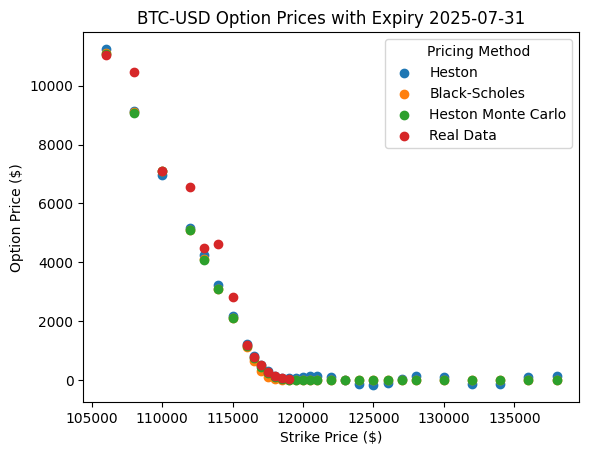

In [ ]:
# Plot Option Prices for Heston and Monte Carlo
plt.scatter(strikes, heston_call_prices, label='Heston')
plt.scatter(strikes, black_scholes_call_prices, label='Black-Scholes')
plt.scatter(strikes, monte_carlo_call_prices, label='Heston Monte Carlo')
plt.scatter(df_calls['strike'], df_calls['lastPrice'], label='Real Data')
plt.xlabel('Strike Price ($)')
plt.ylabel('Option Price ($)')
plt.title('{} Option Prices with Expiry {}'.format(ticker, exp_date))
plt.legend(title="Pricing Method")